In [21]:
#Dataset: /home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/PRNN_2026_A1_data/dataset_2.csv
#Import data set, print number of features and samples:
import pandas as pd
data = pd.read_csv('/home/aadithya-iyer/Github/IIScSecondSem/IISC_PRNN/Assignment 1/PRNN_2026_A1_data/dataset_2.csv')
print("Number of features:", data.shape[1]-1) # Assuming the last column is the target variable
print("Number of samples:", data.shape[0])

Number of features: 1000
Number of samples: 500


# 2.3

In [22]:
#data is the dataframe with the dataset
#We have 1000 features and 500 samples
#So, now, we try to find the OLS solution for the dataset
import numpy as np
# Assuming the last column is the target variable
X = data.iloc[:, :-1].values # Features
y = data.iloc[:, -1].values  # Target variable
# Add a column of ones to X for the intercept term
X = np.hstack((np.ones((X.shape[0], 1)), X))
# Calculate the OLS solution using the normal equation
beta = np.linalg.inv(X.T @ X) @ X.T @ y
print("OLS coefficients:", beta) #We may observe error
#The error: numpy.linalg.LinAlgError: Singular matrix
#But it seems that we are still getting OLS coefficients, which is surprising.
#This might be due to the fact that numpy.linalg.inv is able to handle singular matrices.
#in some cases, or it might be giving us a pseudo-inverse solution.
#However, we should be cautious about interpreting these coefficients,
#as they may not be reliable due to the singularity of the matrix.

#Lets try to exclusively find the inverse of X.T @ X and see if it gives us an error
#Later, also print condition number of X.T @ X to understand the extent of singularity:
try:
    XtX_inv = np.linalg.inv(X.T @ X)
    print("Inverse of X.T @ X calculated successfully.")
except np.linalg.LinAlgError:
    print("Error: X.T @ X is a singular matrix and cannot be inverted.")
#Calculate the condition number of X.T @ X
condition_number = np.linalg.cond(X.T @ X)
print("Condition number of X.T @ X:", condition_number)

OLS coefficients: [2110.11529321 -221.56669699 -178.10702866 ...  -76.54703746   53.26729123
   23.35022072]
Inverse of X.T @ X calculated successfully.
Condition number of X.T @ X: 2.2508001594017485e+19


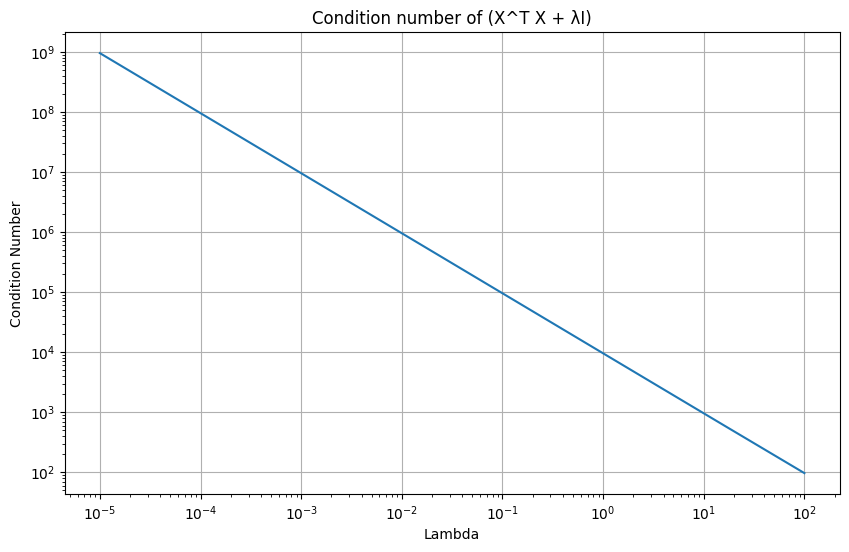

In [23]:
#We observe the condition number is of order 10^19
#Ok, now we try to plot the condition number of (XTX + lambda*I)
#So, vary lambda from 10^-5 to 10^2 and plot the condition number:
import matplotlib.pyplot as plt

XtX = X.T @ X
I = np.eye(X.shape[1])

lambdas = np.logspace(-5, 2, 10)
condition_numbers = []

for lam in lambdas:
    M = XtX + lam * I
    condition_numbers.append(np.linalg.cond(M))

plt.figure(figsize=(10,6))
plt.plot(lambdas, condition_numbers)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Lambda")
plt.ylabel("Condition Number")
plt.title("Condition number of (X^T X + λI)")
plt.grid(True)
plt.show()
#Reduction in condition number is observed

# 2.4

Lambda: 1e-05, Non-zero coefficients: 1001
Lambda: 2.3357214690901213e-05, Non-zero coefficients: 1001
Lambda: 5.4555947811685143e-05, Non-zero coefficients: 1001
Lambda: 0.00012742749857031334, Non-zero coefficients: 1001
Lambda: 0.00029763514416313193, Non-zero coefficients: 1001
Lambda: 0.0006951927961775605, Non-zero coefficients: 1001
Lambda: 0.001623776739188721, Non-zero coefficients: 1001
Lambda: 0.00379269019073225, Non-zero coefficients: 1001
Lambda: 0.008858667904100823, Non-zero coefficients: 1001
Lambda: 0.02069138081114788, Non-zero coefficients: 1000
Lambda: 0.04832930238571752, Non-zero coefficients: 997
Lambda: 0.11288378916846883, Non-zero coefficients: 993
Lambda: 0.26366508987303555, Non-zero coefficients: 980
Lambda: 0.6158482110660255, Non-zero coefficients: 947
Lambda: 1.438449888287663, Non-zero coefficients: 881
Lambda: 3.359818286283781, Non-zero coefficients: 716
Lambda: 7.847599703514606, Non-zero coefficients: 355
Lambda: 18.32980710832434, Non-zero coeffic

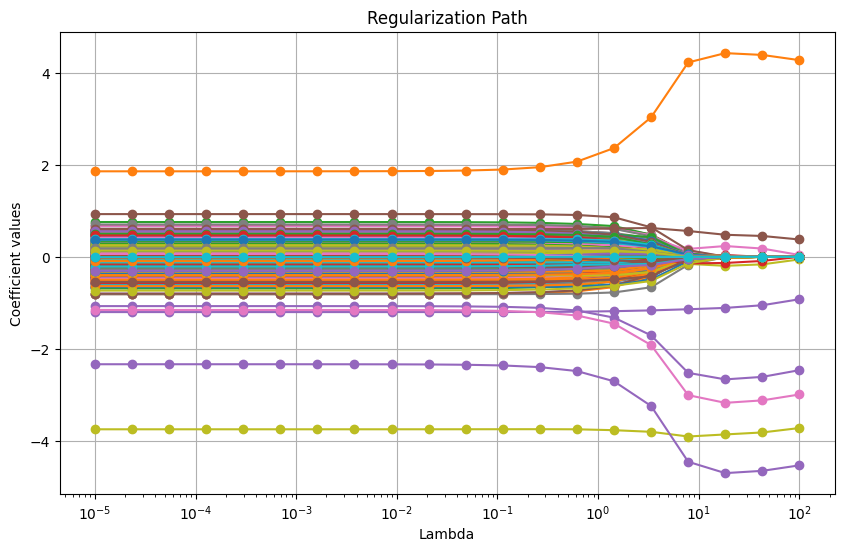

In [24]:
#In this part, we run coordinate descent, with L1 regularization
#Need to plot weight values with log of lambda,
#We need to find that value of lambda for which 50% of weights become zero, from scratch:
#Obj = 0.5 * betaj^2 * Xj^T Xj - betaj * Xj^T (y - X(-j) * beta(-j)) + lambda * |betaj|
#Initialize weights:
beta_path = []

lambdas = np.logspace(-5, 2, 20)

for lam in lambdas:

    beta = np.zeros(X.shape[1])
    r = y.copy()   # residual = y - Xβ , initially β=0

    for iteration in range(20):

        for j in range(len(beta)):

            Xj = X[:, j]

            rho = Xj @ (r + Xj * beta[j])
            z = Xj @ Xj

            beta_old = beta[j]

            if rho < -lam:
                beta[j] = (rho + lam) / z
            elif rho > lam:
                beta[j] = (rho - lam) / z
            else:
                beta[j] = 0

            # update residual efficiently
            r += Xj * (beta_old - beta[j])
    print(f"Lambda: {lam}, Non-zero coefficients: {np.sum(beta != 0)}")

    beta_path.append(beta)

beta_path = np.array(beta_path)
#Create Regularization path plot:
plt.figure(figsize=(10,6))
plt.plot(lambdas, beta_path[:, 1:], marker='o') # Exclude the intercept
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Coefficient values")
plt.title("Regularization Path")
plt.grid(True)
plt.show()

In [26]:
#Upon running, we see lambda values is in bw 3.369 to 7.84
#716 coeff to 355 coeff

low = 3.359818286283781
high = 7.847599703514606

target = 500
#Function for run_lasso_coordinate_descent:
def run_lasso_coordinate_descent(X, y, lam):

    beta = np.zeros(X.shape[1])
    r = y.copy()   # residual = y - Xβ , initially β=0

    for iteration in range(20):

        for j in range(len(beta)):

            Xj = X[:, j]

            rho = Xj @ (r + Xj * beta[j])
            z = Xj @ Xj

            beta_old = beta[j]

            if rho < -lam:
                beta[j] = (rho + lam) / z
            elif rho > lam:
                beta[j] = (rho - lam) / z
            else:
                beta[j] = 0

            # update residual efficiently
            r += Xj * (beta_old - beta[j])
    
    return beta

for _ in range(20):   # ~20 iterations gives good precision
    
    lam = (low + high) / 2
    
    beta = run_lasso_coordinate_descent(X, y, lam)
    
    nonzero = np.sum(np.abs(beta[1:]) > 1e-8)
    
    if nonzero > target:
        low = lam
    else:
        high = lam
    print(f"Lambda: {lam:.4f}, Non-zero coefficients: {nonzero}")
    if nonzero == target:
        break

print("Lambda giving ~50% sparsity:", lam)


Lambda: 5.6037, Non-zero coefficients: 531
Lambda: 6.7257, Non-zero coefficients: 447
Lambda: 6.1647, Non-zero coefficients: 487
Lambda: 5.8842, Non-zero coefficients: 510
Lambda: 6.0244, Non-zero coefficients: 495
Lambda: 5.9543, Non-zero coefficients: 505
Lambda: 5.9894, Non-zero coefficients: 496
Lambda: 5.9718, Non-zero coefficients: 503
Lambda: 5.9806, Non-zero coefficients: 500
Lambda giving ~50% sparsity: 5.9806125123619385
